# Machine Learning Group Project - Transit Reliability and Neighbourhood Equity in Toronto

Training and Predictions


The Data from TTC is joined with the Neighborhood Profiles from the Census, so now we can read it in here

In [1]:
#required imports
import numpy as np
import pandas as pd
import seaborn as sns

# to make this notebook's output stable across runs
np.random.seed(123)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12


In [2]:
# in google colab, mount the google drive to access the data
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
pathToGroup = r"/content/drive/My Drive/Colab Notebooks/GroupProject/"
# pathToGroup = ""

fileName = 'delay_with_neighborhood.xlsx'

dataset = pd.read_excel(pathToGroup+fileName, skiprows= 0, header = 0, index_col = 0)


In the following, you can take a look into the dataset.

In [4]:
dataset.shape

(56206, 63)

In [5]:
# I want to see all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 30)

dataset.head(10)

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,latitude,longitude,AREA_SHORT_CODE,AREA_NAME,AREA_DESC,CLASSIFICATION,CLASSIFICATION_CODE,Total - Age groups of the population - 25% sample data,Median after-tax income of household in 2020 ($),Average after-tax income of household in 2020 ($),Total - Private households by tenure - 25% sample data,Owner,Renter,Total - Citizenship for the population in private households - 25% sample data,Canadian citizens,Not Canadian citizens,Total - Immigrant status and period of immigration for the population in private households - 25% sample data,Non-immigrants,Immigrants,Total - Place of work status for the employed labour force aged 15 years and over - 25% sample data,Worked at home,Worked outside Canada,No fixed workplace address,Usual place of work,Total - Commuting destination for the employed labour force aged 15 years and over with a usual place of work - 25% sample data,Commute within census subdivision (CSD) of residence,Commute to a different census subdivision (CSD) within census division (CD) of residence,Commute to a different census subdivision (CSD) and census division (CD) within province or territory of residence,Commute to a different province or territory,Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,"Car, truck or van","Car, truck or van - as a driver","Car, truck or van - as a passenger",Public transit,Walked,Bicycle,Other method,Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,Less than 15 minutes,15 to 29 minutes,30 to 44 minutes,45 to 59 minutes,60 minutes and over,Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data,Between 5 a.m. and 5:59 a.m.,Between 6 a.m. and 6:59 a.m.,Between 7 a.m. and 7:59 a.m.,Between 8 a.m. and 8:59 a.m.,Between 9 a.m. and 11:59 a.m.,Between 12 p.m. and 4:59 a.m.,Mean Temp (C),Total Precip (mm),Snow on Grnd (cm)
0,2025-01-01,102 MARKHAM ROAD,02:15,Wednesday,WARDEN STATION,MFESA,20,40,N,3442,43.769610,-79.304280,119,Wexford/Maryvale,Wexford/Maryvale (119),Not an NIA or Emerging Neighbourhood,NaN,28345,74000,85800,10260,6050,4220,28340,23620,4720,28340,12365,14400,12445,3120,25,1805,7490,7490,6240,0,1240,10,9300,6300,5485,815,2290,405,35,265,9300,1815,2840,2395,975,1270,9300,650,1285,1905,1845,1665,1950,2.3,0.7,0
1,2025-01-01,65 PARLIAMENT,02:15,Wednesday,KIPLING STATION,MFUS,0,0,NaN,0,43.676448,-79.551377,10,Princess-Rosethorn,Princess-Rosethorn (10),Not an NIA or Emerging Neighbourhood,NaN,11170,133000,164200,3900,3310,590,11170,10460,710,11170,7615,3400,5215,2260,15,490,2450,2450,1770,0,675,0,2940,2435,2230,205,290,95,15,110,2940,640,1085,705,270,240,2940,105,360,730,865,625,260,2.3,0.7,0
2,2025-01-01,64 MAIN,02:40,Wednesday,BROADVIEW STATION,MFUI,0,0,NaN,8546,43.674153,-79.355380,68,North Riverdale,North Riverdale (68),Not an NIA or Emerging Neighbourhood,NaN,11290,93000,127900,4905,2855,2045,11290,10680,610,11290,8395,2720,5760,3145,25,395,2205,2205,2010,0,175,20,2600,1155,1020,130,615,465,270,90,2600,460,1010,725,215,190,2600,40,280,690,770,600,225,2.3,0.7,0
3,2025-01-01,100 FLEMINGDON PARK,02:43,Wednesday,OVERLEA AND THORNCLIFF,MFSAN,17,32,N,8693,43.706435,-79.345772,55,Thorncliffe Park,Thorncliffe Park (55),Neighbourhood Improvement Area,NIA,20400,62400,68500,7065,990,6070,20400,15215,5185,20400,6420,12905,7140,2130,50,1330,3630,3630,3070,0,550,10,4960,2880,2590,285,1465,405,40,165,4960,925,1285,1380,715,655,4960,245,640,985,920,940,1230,2.3,0.7,0
4,2025-01-01,34 EGLINTON EAST,03:05,Wednesday,EGLINTON AND DON MILLS,MFUI,20,40,W,8801,43.720512,-79.338919,42,Banbury-Don Mills,Banbury-Don Mills (42),Not an NIA or Emerging Neighbourhood,NaN,27155,78000,109700,12215,7295,4915,27150,23375,3780,27150,12640,1

We need to do a bunch more data cleaning.  We are not going to train on a lot of these columns, and some columns need to be normalized with others, to become a ratio.  Finally, we need to scalarize, and one-hot encode some columns.

In [7]:
dataset_sm = dataset.copy()

# First, strip leading/trailing whitespace from all column names to ensure matches
dataset_sm.columns = dataset_sm.columns.str.strip()

# Now rename using the cleaned names
dataset_sm.rename(columns={
    'Total - Private households by tenure - 25% sample data' : 'Total Households',
    'Total - Citizenship for the population in private households - 25% sample data': 'Total Citizenship',
    'Total - Immigrant status and period of immigration for the population in private households - 25% sample data': 'Total Status',
    'Total - Place of work status for the employed labour force aged 15 years and over - 25% sample data': 'Total Place Work',
    'Total - Commuting destination for the employed labour force aged 15 years and over with a usual place of work - 25% sample data': 'Total Commute Dest',
    'Total - Main mode of commuting for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data': 'Total Commute Mode',
    'Total - Commuting duration for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data': 'Total Commute Duration',
    'Total - Time leaving for work for the employed labour force aged 15 years and over with a usual place of work or no fixed workplace address - 25% sample data' : 'Total Time for Work',
    'Commute within census subdivision (CSD) of residence' : 'Commute within CSD',
    'Commute to a different census subdivision (CSD) within census division (CD) of residence' : 'Commute btn CSD',
    'Commute to a different census subdivision (CSD) and census division (CD) within province or territory of residence' : 'Commute Intraprovincial',
    'Commute to a different province or territory' : 'Commute Interprovincial'
}, inplace=True)

# Display the new columns to verify
display(dataset_sm.columns.tolist())

['Date',
 'Line',
 'Time',
 'Day',
 'Station',
 'Code',
 'Min Delay',
 'Min Gap',
 'Bound',
 'Vehicle',
 'latitude',
 'longitude',
 'AREA_SHORT_CODE',
 'AREA_NAME',
 'AREA_DESC',
 'CLASSIFICATION',
 'CLASSIFICATION_CODE',
 'Total - Age groups of the population - 25% sample data',
 'Median after-tax income of household in 2020 ($)',
 'Average after-tax income of household in 2020 ($)',
 'Total Households',
 'Owner',
 'Renter',
 'Total Citizenship',
 'Canadian citizens',
 'Not Canadian citizens',
 'Total Status',
 'Non-immigrants',
 'Immigrants',
 'Total Place Work',
 'Worked at home',
 'Worked outside Canada',
 'No fixed workplace address',
 'Usual place of work',
 'Total Commute Dest',
 'Commute within CSD',
 'Commute btn CSD',
 'Commute Intraprovincial',
 'Commute Interprovincial',
 'Total Commute Mode',
 'Car, truck or van',
 'Car, truck or van - as a driver',
 'Car, truck or van - as a passenger',
 'Public transit',
 'Walked',
 'Bicycle',
 'Other method',
 'Total Commute Duration',


# Data Exploration

Some questions we want to answers to are the following:

*   When (during the day) are delays most likely to occur?
*   When (during the week) are delays most likely to occur?
*   Where are the delays most likly to occur? Do we look at the neighborhood numbers first? Or do we use longitude/latitudes?
*   Are the amount of delays correlated with number of commuters, or avg income, or commute destinations, etc?




In [8]:
# reduce the dataset to only include data from 2025,
# since the weather data is only from 2025
dataset_sm = dataset_sm[dataset_sm['Date'].dt.year == 2025]

In [9]:
dataset_sm['Min Delay'].describe()

,Min Delay
count,51447.000000
mean,19.421599
std,45.408051
min,0.000000
25%,8.000000
50%,11.000000
75%,20.000000
max,999.000000


### How long do delays last?

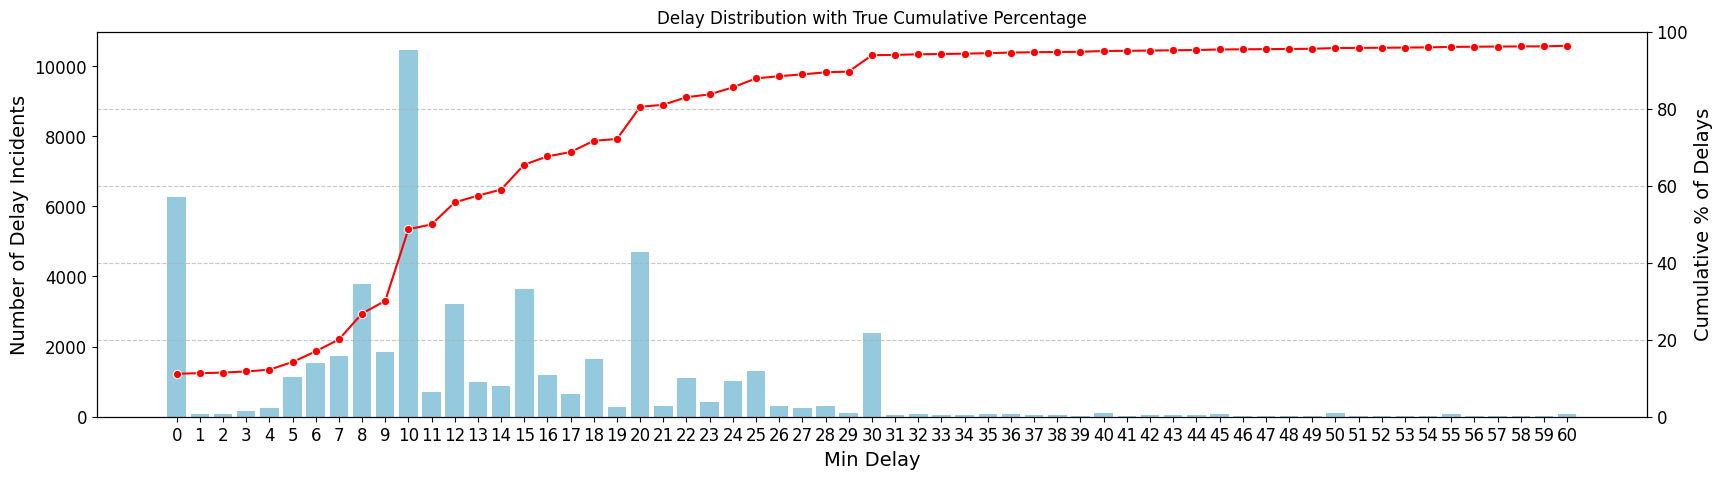

In [10]:
full_stats = dataset.groupby('Min Delay').size().reset_index(name='Incident Count')
full_stats = full_stats.sort_values('Min Delay')

# get the cumulative %
full_stats['Cumulative Count'] = full_stats['Incident Count'].cumsum()
full_stats['Cumulative %'] = 100 * full_stats['Cumulative Count'] / full_stats['Incident Count'].sum()

# limit plot to 1 hour
stats_by_delay = full_stats[full_stats['Min Delay'] <= 60]

fig, ax1 = plt.subplots(figsize=(20, 5))

# Bar plot (counts)
sns.barplot(
    x='Min Delay',
    y='Incident Count',
    data=stats_by_delay,
    ax=ax1,
    color='skyblue'
)

ax1.set_xlabel('Min Delay')
ax1.set_ylabel('Number of Delay Incidents')

ax2 = ax1.twinx()

sns.lineplot(
    x='Min Delay',
    y='Cumulative %',
    data=stats_by_delay,
    ax=ax2,
    marker='o',
    color='red'
)

ax2.set_ylabel('Cumulative % of Delays')
ax2.set_ylim(0, 100)

plt.title('Delay Distribution with True Cumulative Percentage')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## When Do Delay events occur?


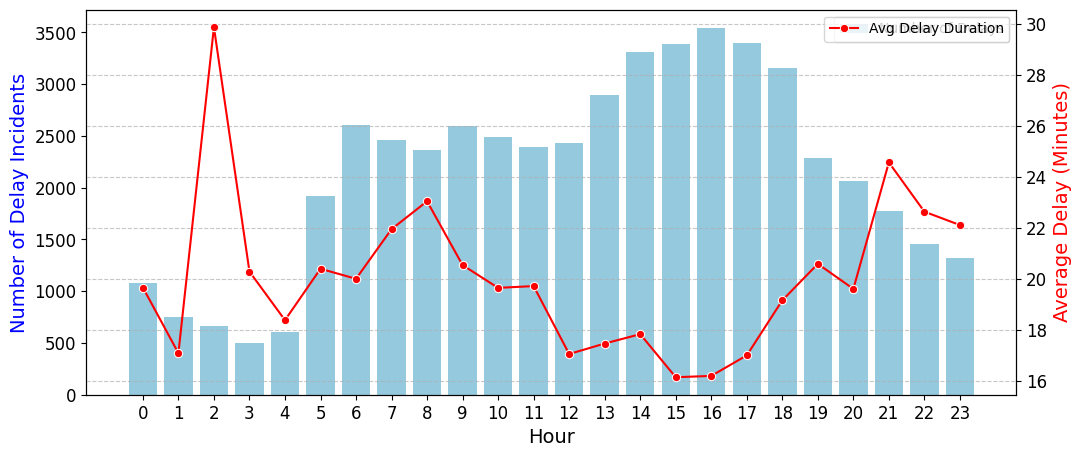

In [ ]:
# Need to parse out the hour in the time column, and aggregate by it
# Hour is in string like, '04:38'
dataset_sm['Hour'] = dataset_sm['Time'].apply(lambda x: int(str(x).split(':')[0]) if ':' in str(x) else None)

# Group by hour
stats_by_hour = dataset_sm.groupby('Hour').agg({'Min Delay' : ['count', 'mean']}).reset_index()
stats_by_hour.columns = ['Hour', 'Incident Count', 'Average Delay (Min)']

# graph it
fig, ax1 = plt.subplots(figsize=(12, 5))
sns.barplot(x='Hour', y='Incident Count',
            data=stats_by_hour, ax=ax1, color='skyblue', label='Number of Delays')
ax1.set_ylabel('Number of Delay Incidents', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x='Hour', y='Average Delay (Min)', data=stats_by_hour,
             ax=ax2, color='red', marker='o', label='Avg Delay Duration')
ax2.set_ylabel('Average Delay (Minutes)', color='red')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the graph, it looks like the number of incident reports is highest between 5am and 8pm.  The hours between 1am and 5am sees the least number of incidents.  However, the delays experienced at this time seem to be the highest.  

## Effect of the Days of the week on Delay Events



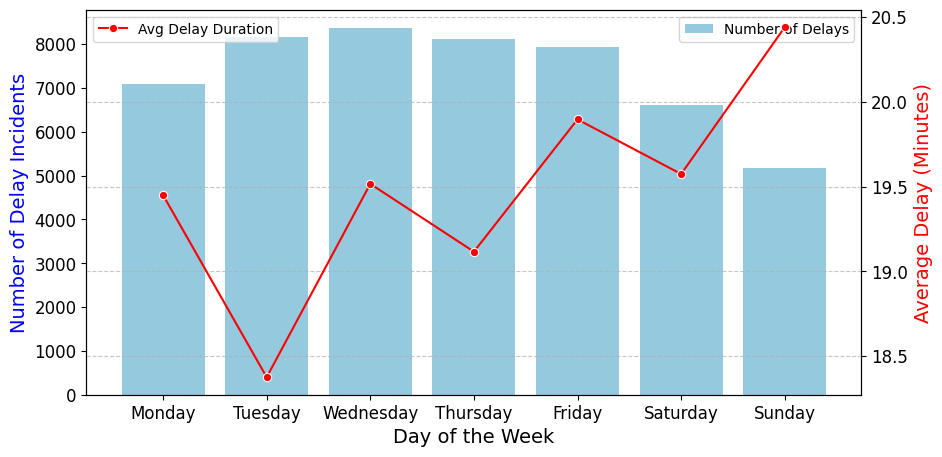

In [ ]:
# Going to aggregate by the Day of the week
stats_by_day = dataset_sm.groupby('Day').agg({'Min Delay' : ['count', 'mean']}).reset_index()
stats_by_day.columns = ['Day', 'Incident Count', 'Average Delay (Min)']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reorder the rows by converting 'Day' to a categorical type and sorting
stats_by_day['Day'] = pd.Categorical(stats_by_day['Day'], categories=day_order, ordered=True)
stats_by_day = stats_by_day.sort_values('Day')

# graph it
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(x='Day', y='Incident Count',
            data=stats_by_day, ax=ax1, color='skyblue', label='Number of Delays')
ax1.set_ylabel('Number of Delay Incidents', color='blue')

ax2 = ax1.twinx()
sns.lineplot(x='Day', y='Average Delay (Min)', data=stats_by_day,
             ax=ax2, color='red', marker='o', label='Avg Delay Duration')
ax2.set_ylabel('Average Delay (Minutes)', color='red')

plt.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_xlabel('Day of the Week')
plt.show()

We can see that while we have fewer incidents on Sundays, the average delay is also the highest on Sundays.

## Which neighborhoods have the most delay?



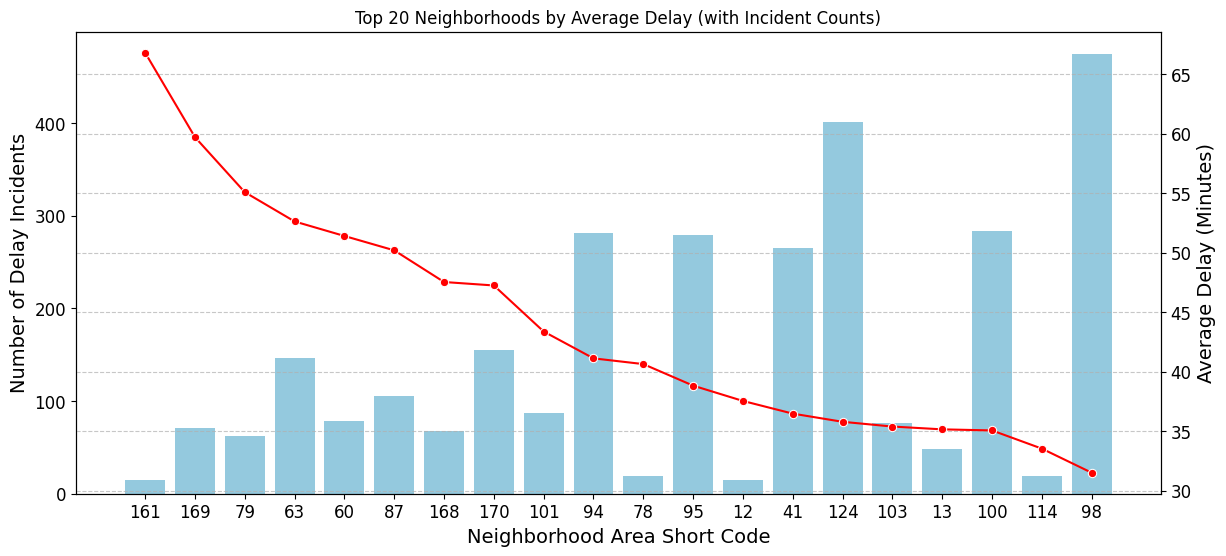

In [11]:
# Aggregate by AREA_SHORT_CODE
stats_by_area = dataset_sm.groupby('AREA_SHORT_CODE').agg({
    'Min Delay': ['count', 'mean']
}).reset_index()

stats_by_area.columns = ['AREA_SHORT_CODE', 'Incident Count', 'Average Delay (Min)']

# Sort by Average Delay and take top 20
top_20_areas = stats_by_area.sort_values(
    'Average Delay (Min)',
    ascending=False
).head(20)

# Ensure categorical x-axis
top_20_areas['AREA_SHORT_CODE'] = top_20_areas['AREA_SHORT_CODE'].astype(str)

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar: Incident Count
sns.barplot(
    x='AREA_SHORT_CODE',
    y='Incident Count',
    data=top_20_areas,
    ax=ax1,
    color='skyblue'
)

ax1.set_ylabel('Number of Delay Incidents')
ax1.set_xlabel('Neighborhood Area Short Code')

# Line: Average Delay
ax2 = ax1.twinx()

sns.lineplot(
    x='AREA_SHORT_CODE',
    y='Average Delay (Min)',
    data=top_20_areas,
    ax=ax2,
    marker='o',
    color='red'
)

ax2.set_ylabel('Average Delay (Minutes)')

plt.title('Top 20 Neighborhoods by Average Delay (with Incident Counts)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
import folium

# Get the original coordinates for the top 20 areas
# We ensure AREA_SHORT_CODE is a string to match top_20_areas
top_20_coords = dataset[['AREA_SHORT_CODE', 'latitude', 'longitude', 'AREA_NAME']].drop_duplicates('AREA_SHORT_CODE').copy()
top_20_coords['AREA_SHORT_CODE'] = top_20_coords['AREA_SHORT_CODE'].astype(str)

top_20_map_data = top_20_areas.merge(top_20_coords, on='AREA_SHORT_CODE', how='left')

# Create a map centered around Toronto
m = folium.Map(location=[43.7, -79.4], zoom_start=11)

# Add markers for each of the top 20 neighborhoods
for idx, row in top_20_map_data.iterrows():
    if pd.notnull(row['latitude']) and pd.notnull(row['longitude']):
        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=f"Area: {row['AREA_NAME']}<br>Avg Delay: {row['Average Delay (Min)']:.2f} min",
            tooltip=row['AREA_NAME'],
            icon=folium.Icon(color='red', icon='info-sign')
        ).add_to(m)

display(m)

### How does weather play a factor?

/tmp/ipykernel_599/1565955496.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_temp = dataset.groupby('Temp Bin').agg({


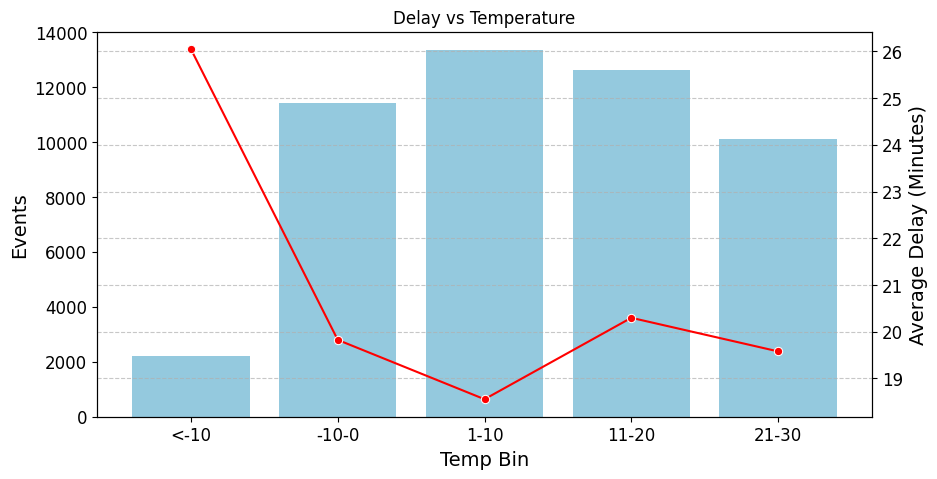

In [12]:
# Create delay flag
dataset['Has Delay'] = (dataset['Min Delay'] > 0).astype(int)

# Bin temperature
dataset['Temp Bin'] = pd.cut(
    dataset['Mean Temp (C)'],
    bins=[-20, -10, 0, 10, 20, 30],
    labels=['<-10', '-10-0', '1-10', '11-20', '21-30']
)

# Aggregate
stats_temp = dataset.groupby('Temp Bin').agg({
    'Has Delay': 'sum',      # <-- COUNT of delayed events
    'Min Delay': 'mean'
}).reset_index()

stats_temp.columns = ['Temp Bin', 'Incident Count', 'Avg Delay']

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='Temp Bin',
    y='Incident Count',
    data=stats_temp,
    ax=ax1,
    color='skyblue'
)

ax1.set_ylabel('Events')

ax2 = ax1.twinx()

sns.lineplot(
    x='Temp Bin',
    y='Avg Delay',
    data=stats_temp,
    ax=ax2,
    marker='o',
    color='red'
)

ax2.set_ylabel('Average Delay (Minutes)')

plt.title('Delay vs Temperature')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

/tmp/ipykernel_599/331431179.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_precip = dataset.groupby('Precip Bin').agg({


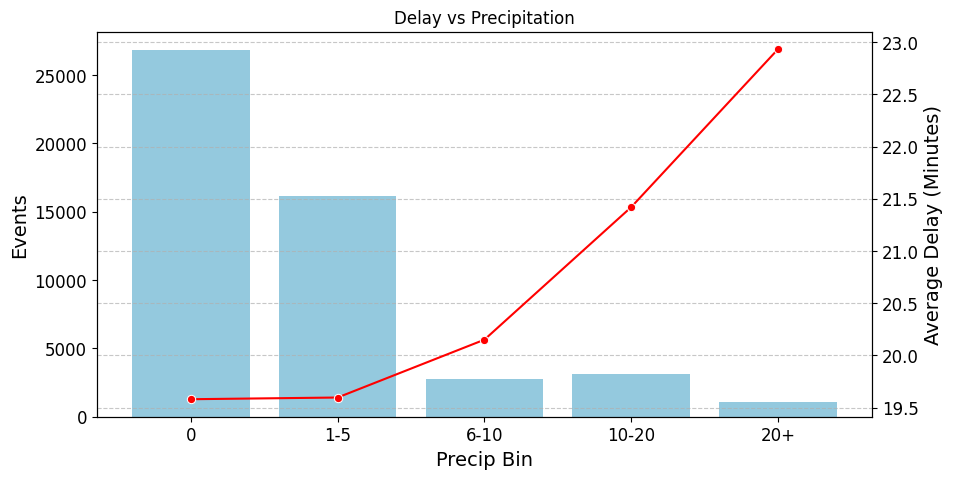

In [13]:
# Bin precipitation
dataset['Precip Bin'] = pd.cut(
    dataset['Total Precip (mm)'],
    bins=[-0.1, 0, 5, 10, 20, float('inf')],
    labels=['0', '1-5', '6-10', '10-20', '20+'],
)

# Aggregate
stats_precip = dataset.groupby('Precip Bin').agg({
    'Has Delay': 'sum',     # <-- count instead of mean
    'Min Delay': 'mean'
}).reset_index()

stats_precip.columns = ['Precip Bin', 'Incident Count', 'Avg Delay']

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='Precip Bin',
    y='Incident Count',
    data=stats_precip,
    ax=ax1,
    color='skyblue'
)

ax1.set_ylabel('Events')

ax2 = ax1.twinx()

sns.lineplot(
    x='Precip Bin',
    y='Avg Delay',
    data=stats_precip,
    ax=ax2,
    marker='o',
    color='red'
)

ax2.set_ylabel('Average Delay (Minutes)')

plt.title('Delay vs Precipitation')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

/tmp/ipykernel_599/685566761.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_snow = dataset.groupby('Snow On Ground (cm)').agg({


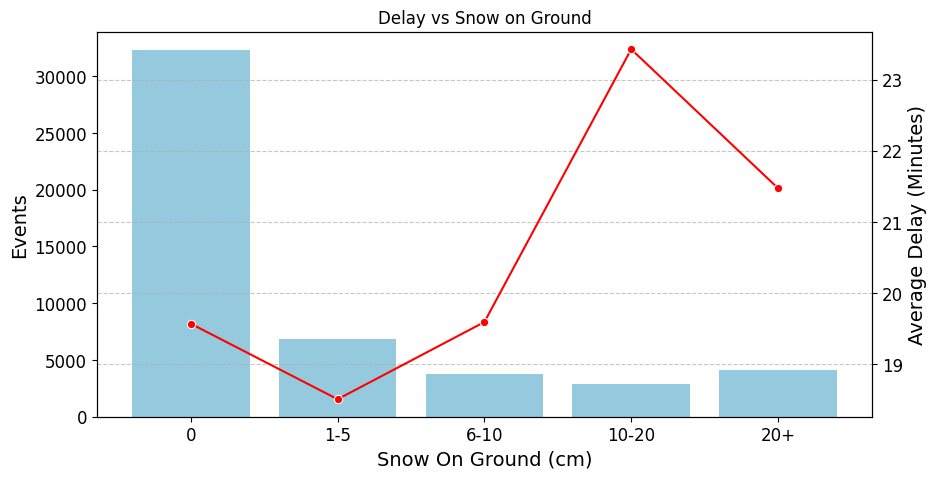

In [14]:
# Bin snow
dataset['Snow On Ground (cm)'] = pd.cut(
    dataset['Snow on Grnd (cm)'],
    bins=[-0.1, 0, 5, 10, 20, float('inf')],
    labels=['0', '1-5', '6-10', '10-20', '20+'],
)

# Aggregate
stats_snow = dataset.groupby('Snow On Ground (cm)').agg({
    'Has Delay': 'sum',     # <-- count instead of mean
    'Min Delay': 'mean'
}).reset_index()

stats_snow.columns = ['Snow On Ground (cm)', 'Incident Count', 'Avg Delay']

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='Snow On Ground (cm)',
    y='Incident Count',
    data=stats_snow,
    ax=ax1,
    color='skyblue'
)

ax1.set_ylabel('Events')

ax2 = ax1.twinx()

sns.lineplot(
    x='Snow On Ground (cm)',
    y='Avg Delay',
    data=stats_snow,
    ax=ax2,
    marker='o',
    color='red'
)

ax2.set_ylabel('Average Delay (Minutes)')

plt.title('Delay vs Snow on Ground')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Features of Dataset



Instead of using the 'Time' feature in our model, we are using the 'Hour' because the minutes don't matter as much and can overly complicate things.

In [ ]:
# Want to parse out the Month from the Date, and give our training model
# more data
dataset_sm['Month'] = dataset_sm['Date'].apply(lambda x: int(str(x).split('-')[1]))



In [ ]:
# drop rows where delay is 0
dataset_sm = dataset_sm[dataset_sm['Min Delay'] > 0]

# Our Target is the Min Delay (we can do the same with Min Gap)
y_target_label = 'Min Delay'

datay = dataset_sm[y_target_label]

# what columns of data do we want to train on?
cols_to_train_with = ['Month',
                      'Hour', #'Time',
                      'Day', #'Station',
                      #'Line Number',
                      'Bound',
                      'Total - Age groups of the population - 25% sample data',
                      'Median after-tax income of household in 2020 ($)',
                      'Owner', 'Renter',
                      'Worked at home',
                      'Worked outside Canada',
                      'Usual place of work',
                      'Commute within CSD',
                      'Commute btn CSD',
                      'Commute Intraprovincial',
                      'Commute Interprovincial',
                      'Car, truck or van',
                      'Car, truck or van - as a driver',
                      'Car, truck or van - as a passenger',
                      'Public transit',
                      'Walked',
                      'Bicycle',
                      'Other method',
                      'Less than 15 minutes',
                      '15 to 29 minutes',
                      '30 to 44 minutes',
                      '45 to 59 minutes',
                      '60 minutes and over',
                      'Mean Temp (°C)',
                      'Total Precip (mm)',
                      'Snow on Grnd (cm)']

cols_categorical = ['Day', 'Bound']
cols_numerical = [#'Hour',
                  'Total - Age groups of the population - 25% sample data',
                  'Median after-tax income of household in 2020 ($)',
                  'Owner', 'Renter',
                  'Worked at home',
                  'Worked outside Canada',
                  'Usual place of work',
                  'Commute within CSD',
                  'Commute btn CSD',
                  'Commute Intraprovincial',
                  'Commute Interprovincial',
                  'Car, truck or van',
                  'Car, truck or van - as a driver',
                  'Car, truck or van - as a passenger',
                  'Public transit',
                  'Walked',
                  'Bicycle',
                  'Other method',
                  'Less than 15 minutes',
                  '15 to 29 minutes',
                  '30 to 44 minutes',
                  '45 to 59 minutes',
                  '60 minutes and over',
                  'Mean Temp (°C)',
                  'Total Precip (mm)',
                  'Snow on Grnd (cm)']
dataX = dataset_sm[cols_to_train_with]

dataX.shape

(45673, 30)

I would like to split the data into the test set and the training set, but immediately came across reframing the problem.  Apparently there is a very high number that only exists once in the 'Min Delay' column.  The train_test_split function could not stratify the data because this single data point cannot be put in both training and test set.

I have 2 options:  I can either not stratify the data, or I can convert this regression problem into a classification problem, and sort the 'Min Delay' into bins of, say, 10-minute chunks.  For our project, I think it makes more sense to bin the 'Min Delay' into 10-min chunks, because it is probably unreasonable to be able to predict delays to the minute.  It may be helpful already to be able to predict that the 'Min Delay' will be around 40 to 50 minutes, then you can find other forms of transportation, or just give up going in for work and work from home instead.  So I am reframing my original regression problem into a multi-class classification problem.  If I still run into the problem where I still cannot stratify, I think I will just increase the bin sizes, or maybe the last bin will just be a 'greater than X minutes' rather than a strict 10-minute duration.

But even before that, I want to try using KMeans to cluster the data to see what groups of delays I have.  Perhaps 10-min intervals are too fine-grained.  Also, it's possible the time duration of bins should increase as time increases.   

# Clustering of Min Delay Data


Let's see if we can use KMeans clustering to classify our data.  This will tell us if there is anything useful in our dataset.

In [ ]:
# Create cyclic features for Month
dataset_sm['Month_sin'] = np.sin(2 * np.pi * dataset_sm['Month'] / 12)
dataset_sm['Month_cos'] = np.cos(2 * np.pi * dataset_sm['Month'] / 12)

# Create cyclic features for Hour
# Hour ranges from 0 to 23
dataset_sm['Hour_sin'] = np.sin(2 * np.pi * dataset_sm['Hour'] / 24)
dataset_sm['Hour_cos'] = np.cos(2 * np.pi * dataset_sm['Hour'] / 24)

# Define the updated numerical columns including the new cyclic features
# We exclude the original 'Month' and 'Hour' because they are now represented by sin/cos
cols_cyclic = ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']

In [ ]:
data_to_cluster = dataset_sm[cols_to_train_with + cols_cyclic + [y_target_label]].copy()

# drop the 'Month' and 'Hour' columns
data_to_cluster.drop(columns=['Month', 'Hour'], inplace=True)

data_to_cluster.head()

,Day,Bound,Total - Age groups of the population - 25% sample data,Median after-tax income of household in 2020 ($),Owner,Renter,Worked at home,Worked outside Canada,Usual place of work,Commute within CSD,Commute btn CSD,Commute Intraprovincial,Commute Interprovincial,"Car, truck or van","Car, truck or van - as a driver","Car, truck or van - as a passenger",Public transit,Walked,Bicycle,Other method,Less than 15 minutes,15 to 29 minutes,30 to 44 minutes,45 to 59 minutes,60 minutes and over,Mean Temp (°C),Total Precip (mm),Snow on Grnd (cm),Month_sin,Month_cos,Hour_sin,Hour_cos,Min Delay
0,Wednesday,N,28345,74000,6050,4220,3120,25,7490,6240,0,1240,10,6300,5485,815,2290,405,35,265,1815,2840,2395,975,1270,2.3,0.7,0.0,0.5,0.866025,0.500000,0.866025,20
3,Wednesday,N,20400,62400,990,6070,2130,50,3630,3070,0,550,10,2880,2590,285,1465,405,40,165,925,1285,1380,715,655,2.3,0.7,0.0,0.5,0.866025,0.500000,0.866025,17
4,Wednesday,W,27155,78000,7295,4915,5305,190,5850,4940,0,895,15,5015,4540,480,1145,335,65,270,1130,2610,1865,600,635,2.3,0.7,0.0,0.5,0.866025,0.707107,0.707107,20
7,Wednesday,N,17700,61600,3990,7065,6140,45,3825,3380,0,420,25,1145,980,165,1150,1655,195,160,1065,1565,950,390,345,2.3,0.7,0.0,0.5,0.866025,0.707107,0.707107,5
9,Wednesday,W,27540,76500,7135,1950,2885,80,6570,4670,0,1895,10,6045,5120,920,1465,190,55,140,1315,2515,2095,795,1170,2.3,0.7,0.0,0.5,0.866025,0.866025,0.500000,16


In [ ]:
data_to_cluster.shape

(45673, 33)

In [ ]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pipeline_categorical = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown="ignore")),
])

pipeline_numerical = Pipeline([
  #('scaler', MinMaxScaler(feature_range=(0,1))),
  ('scaler', StandardScaler())
])

# We should include the target label in the numerical pipeline so it doesn't dominate by scale
#cols_to_scale = cols_numerical + ['Month', 'Hour', y_target_label]
cols_to_scale = cols_numerical + [y_target_label]

pipeline_for_clustering = ColumnTransformer([
  ("categorical", pipeline_categorical, cols_categorical),
  ("numerical", pipeline_numerical, cols_to_scale),
])

# Fit and transform the data
data_to_cluster_transformed = pipeline_for_clustering.fit_transform(data_to_cluster)

print(f"data_to_cluster_transformed.shape: {data_to_cluster_transformed.shape}")

data_to_cluster_transformed.shape: (45673, 47)


In [ ]:
import numpy as np

# Create cyclic features for Month
#data_to_cluster['Month_sin'] = np.sin(2 * np.pi * data_to_cluster['Month'] / 12)
#data_to_cluster['Month_cos'] = np.cos(2 * np.pi * data_to_cluster['Month'] / 12)

# Create cyclic features for Hour
# Hour ranges from 0 to 23
#data_to_cluster['Hour_sin'] = np.sin(2 * np.pi * data_to_cluster['Hour'] / 24)
#data_to_cluster['Hour_cos'] = np.cos(2 * np.pi * data_to_cluster['Hour'] / 24)

# Define the updated numerical columns including the new cyclic features
# We exclude the original 'Month' and 'Hour' because they are now represented by sin/cos
#cols_cyclic = ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']
cols_to_scale_updated = cols_numerical + cols_cyclic + [y_target_label]

# Update the pipeline
pipeline_for_clustering_cyclic = ColumnTransformer([
  ("categorical", pipeline_categorical, cols_categorical),
  ("numerical", pipeline_numerical, cols_to_scale_updated),
])

# Transform the data
data_to_cluster_transformed = pipeline_for_clustering_cyclic.fit_transform(data_to_cluster)

print(f"New transformed shape: {data_to_cluster_transformed.shape}")
#display(data_to_cluster[['Month', 'Month_sin', 'Month_cos', 'Hour', 'Hour_sin', 'Hour_cos']].head())

New transformed shape: (45673, 51)


In [ ]:
#data_to_cluster_transformed[:10]

In [ ]:
def getInertia(X,kmeans):
    inertia = 0
    for J in range(len(X)):
        inertia = inertia + np.linalg.norm(X[J] - kmeans.cluster_centers_[kmeans.labels_[J]])**2
    return inertia

In [ ]:
from sklearn import metrics
from sklearn.cluster import KMeans
import numpy as np

kmeans_results = np.zeros(11)
result_silhouette = np.zeros(11)

# Loop over k values using the transformed data (one-hot encoded + raw numerical)
for k in range(0, 10):
    kmeans_model = KMeans(n_clusters=k+1, random_state=0, n_init=10).fit(data_to_cluster_transformed)
    kmeans_results[k+1] = kmeans_model.inertia_
    if k > 0:
        result_silhouette[k+1] = metrics.silhouette_score(data_to_cluster_transformed, kmeans_model.labels_, metric='euclidean')
    print(f"k = {k+1}, inertial_value = {kmeans_results[k+1]:.2f}, silhouette = {result_silhouette[k+1]:.4f}")

k = 1, inertial_value = 1445530.84, silhouette = 0.0000
k = 2, inertial_value = 1072999.66, silhouette = 0.2249
k = 3, inertial_value = 938566.95, silhouette = 0.2369
k = 4, inertial_value = 850255.21, silhouette = 0.1519
k = 5, inertial_value = 799457.13, silhouette = 0.1608
k = 6, inertial_value = 763303.72, silhouette = 0.1674
k = 7, inertial_value = 741677.41, silhouette = 0.1457
k = 8, inertial_value = 707051.57, silhouette = 0.1560
k = 9, inertial_value = 694034.68, silhouette = 0.1507
k = 10, inertial_value = 660508.30, silhouette = 0.1686


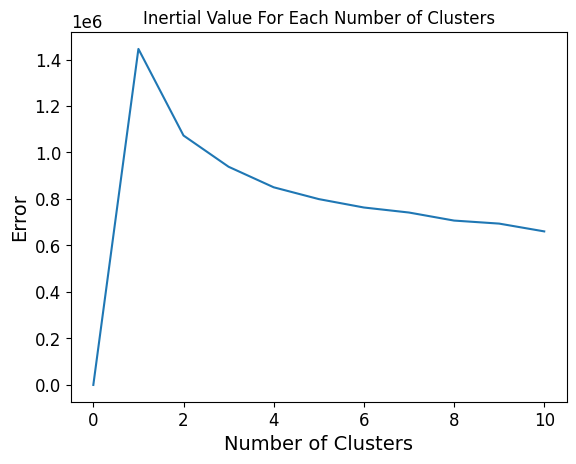

In [ ]:
plt.plot(kmeans_results)
plt.title('Inertial Value For Each Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Error')
plt.show()

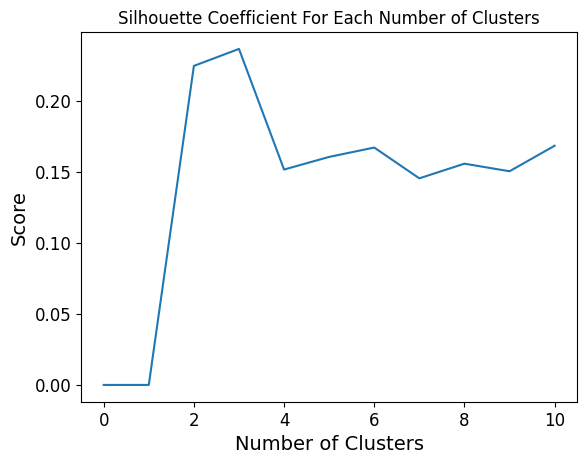

In [ ]:
plt.plot(result_silhouette)
plt.title('Silhouette Coefficient For Each Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.show()

From the above graphs, we can see that the data can be partititions quite successfully into 2 to 3 clusters.  For 2 clusters, the silhouette coefficient is 0.25, whereas it is 0.26 for 3 clusters.  If we attempt to increase the number of clusters beyond that, the silhouette drops to hover around 0.17.  

In [ ]:
kmeans2 = KMeans(n_clusters=2, random_state=0).fit(data_to_cluster_transformed)

cluster_labels = kmeans2.labels_
print(cluster_labels)
cluster_labels.shape

[0 1 0 ... 0 1 1]


(45673,)

# Peforming PCA on Dataset

We want to know whether all the data we have gathered is actually useful or not.  Thus we perform PCA to see the number of dimensions we require to preserve 95% of the dataset variance.

In [ ]:
from sklearn.decomposition import PCA

pca_all = PCA()
pca_all.fit(data_to_cluster_transformed)

cumsum = np.cumsum(pca_all.explained_variance_ratio_)

num_components = np.argmax(cumsum >=0.95) + 1

print('The number of dimensions required to preserve 95% of dataset variance is {}.'.format(num_components))

The number of dimensions required to preserve 95% of dataset variance is 20.


We found that we need at least 19 dimensions.  This is good news since this means that we actually do need most of features we have in the dataset.  Now we will see if we can map the dimensions back to the features in our dataset, to see if we can determine what the top 5 most important features are.

In [ ]:
pca_try = PCA(n_components=0.95)
#X_train_reduced = pca_try.fit_transform(X_train)
X_train_reduced = pca_try.fit_transform(data_to_cluster_transformed)

In [ ]:
pca_try.explained_variance_ratio_


array([0.3798301 , 0.14053752, 0.07335233, 0.05878115, 0.034985  ,
       0.03373348, 0.03192643, 0.03116782, 0.02805646, 0.02679126,
       0.02349637, 0.01805691, 0.01470005, 0.01335527, 0.01028855,
       0.00789143, 0.00721724, 0.00658522, 0.00615788, 0.00518973])

In [ ]:
import pandas as pd
import numpy as np

# Correctly extract feature names from the cyclic pipeline
# This ensures the names match the 48 features produced by the transformer
cat_features = pipeline_for_clustering_cyclic.named_transformers_['categorical'].get_feature_names_out(cols_categorical).tolist()
num_features = cols_to_scale_updated
feature_names = cat_features + num_features

# Create a DataFrame with the PCA components
pc_indices = [f'PC{i+1}' for i in range(pca_try.n_components_)]
components_df = pd.DataFrame(
    pca_try.components_,
    columns=feature_names,
    index=pc_indices
)

# Get the top 5 features based on the first Principal Component (PC1)
top_5_features = components_df.iloc[0].abs().sort_values(ascending=False).head(5)

print("--- Top 5 Most Important Features from PCA ---")
display(top_5_features)

--- Top 5 Most Important Features from PCA ---


Usual place of work                                       0.287082
30 to 44 minutes                                          0.277248
15 to 29 minutes                                          0.277048
Total - Age groups of the population - 25% sample data    0.276505
Commute within CSD                                        0.272486
Name: PC1, dtype: float64

# Exploration using tSNE to figure out what our clusters should be


We want to know if there are patterns to these delays, and whether tSNE can help us determine this graphically.

In [ ]:
# create a new column called 'Min Delay Temporary', that keys off 'Min Delay'
# is 0 if 'Min Delay' is 0
# is 1 if 'Min Delay' is between 1-10
# is 2 if 'Min Delay' is between 11-20
# is 3 if 'Min Delay' is between 21-30 etc
dataset_sm['Min Delay Temporary'] = pd.cut(dataset_sm['Min Delay'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, float('inf')],
                                        right=True, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])



In [ ]:
data_for_tsne = dataset_sm[cols_categorical + cols_numerical + cols_cyclic]

In [ ]:
# import TSNE from sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.manifold     import TSNE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Correct column name for the binned delay. 'Min Delay Temp' should be 'Min Delay Temporary'.
cols_to_scale_tsne = cols_numerical + cols_cyclic

# Redefine pipeline_numerical to include the imputer. The imputer should be applied to numerical features.
pipeline_numerical_with_imputer = Pipeline([
  ('imputer', SimpleImputer(strategy='median')), # Impute numerical columns before scaling
  ('scaler', StandardScaler())
])

# Create a ColumnTransformer for preprocessing all features
preprocessor_for_tsne = ColumnTransformer(transformers=[
  ("categorical", pipeline_categorical, cols_categorical),
  ("numerical", pipeline_numerical_with_imputer, cols_to_scale_tsne),
])

# Now construct the final pipeline including the preprocessor and TSNE
tsne_pipeline = Pipeline([
  ('preprocessor', preprocessor_for_tsne),
  ('tsne',    TSNE(n_components=2, verbose=1, perplexity=40, max_iter=300)),
])
import time
tsne_start = time.time()
# Transform the data
tsne_result = tsne_pipeline.fit_transform(data_for_tsne)
tsne_end = time.time()
print(f"t-SNE took {tsne_end - tsne_start:.4f} seconds to run")


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 45673 samples in 0.000s...
[t-SNE] Computed neighbors for 45673 samples in 1.024s...
[t-SNE] Computed conditional probabilities for sample 1000 / 45673
[t-SNE] Computed conditional probabilities for sample 2000 / 45673
[t-SNE] Computed conditional probabilities for sample 3000 / 45673
[t-SNE] Computed conditional probabilities for sample 4000 / 45673
[t-SNE] Computed conditional probabilities for sample 5000 / 45673
[t-SNE] Computed conditional probabilities for sample 6000 / 45673
[t-SNE] Computed conditional probabilities for sample 7000 / 45673
[t-SNE] Computed conditional probabilities for sample 8000 / 45673
[t-SNE] Computed conditional probabilities for sample 9000 / 45673
[t-SNE] Computed conditional probabilities for sample 10000 / 45673
[t-SNE] Computed conditional probabilities for sample 11000 / 45673
[t-SNE] Computed conditional probabilities for sample 12000 / 45673
[t-SNE] Computed conditional probabilities for sa

/var/folders/59/pvshlnnj7ql721hbsyb3wx4c0000gn/T/ipykernel_20106/1353633186.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_for_tsne['tsne-2d-one'] = tsne_result[:, 0]
/var/folders/59/pvshlnnj7ql721hbsyb3wx4c0000gn/T/ipykernel_20106/1353633186.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_for_tsne['tsne-2d-two'] = tsne_result[:, 1]
/var/folders/59/pvshlnnj7ql721hbsyb3wx4c0000gn/T/ipykernel_20106/1353633186.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

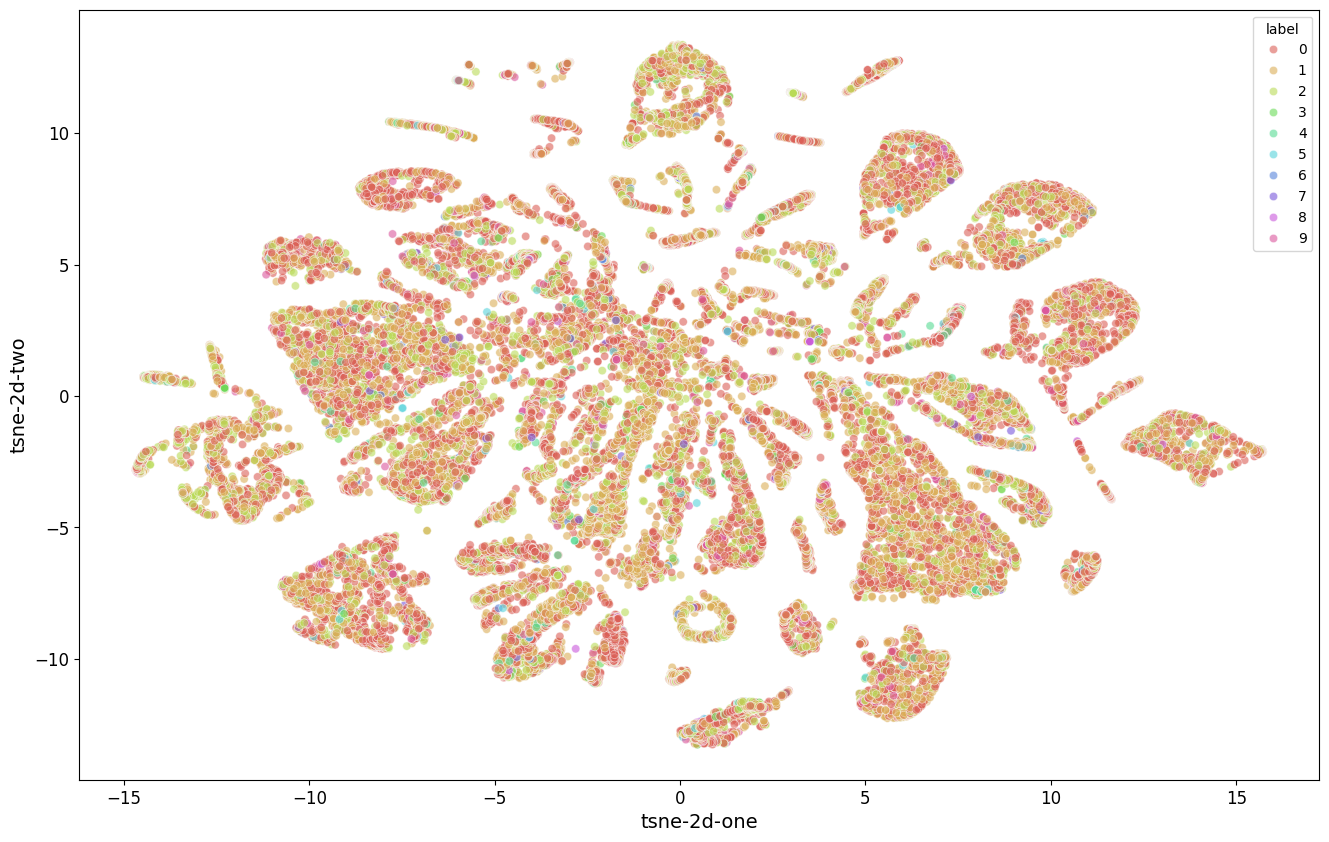

In [ ]:
data_for_tsne['tsne-2d-one'] = tsne_result[:, 0]
data_for_tsne['tsne-2d-two'] = tsne_result[:, 1]

# Add the 'label' column for plotting
# Ensure the indices match. X_df_subset is loc[:N] so y_train.loc[:N] should match.
data_for_tsne['label'] = dataset_sm['Min Delay Temporary']

plt.figure(figsize=(16,10))
sns.scatterplot(x='tsne-2d-one', y='tsne-2d-two', hue='label',
               palette=sns.color_palette('hls', 10),
               data=data_for_tsne,
               alpha=0.6)
plt.show()

From the t-SNE plot, we can see clear separation of clusters when I grouped the delays into 10-minute intervals.  However, each group has a smattering of different delays. There appear to be groups, but there is no clear clustering of higher delay points in clear groups.  To try to get more of an understanding, I computed the silhoeutte score for my t-SNE plot.

In [ ]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score for the binned labels in the t-SNE space
# This measures how well the delay bins are separated in the 2D plot
score = silhouette_score(tsne_result, dataset_sm['Min Delay Temporary'])

print(f't-SNE Label Separation Score (Silhouette): {score:.4f}')

# Let's also check the distribution of labels to see if one class dominates the clusters
display(data_for_tsne.groupby('label').agg({'tsne-2d-one': ['mean', 'std'], 'tsne-2d-two': ['mean', 'std']}))

t-SNE Label Separation Score (Silhouette): -0.0488


/var/folders/59/pvshlnnj7ql721hbsyb3wx4c0000gn/T/ipykernel_20106/2279770148.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(data_for_tsne.groupby('label').agg({'tsne-2d-one': ['mean', 'std'], 'tsne-2d-two': ['mean', 'std']}))


tsne-2d-one            \
             mean       std   
label                         
0        0.077563  6.732374   
1        0.248800  6.623194   
2       -0.675792  6.568744   
3        0.310984  6.087873   
4       -0.368284  6.627182   
5       -0.169141  6.671879   
6       -0.674971  5.875079   
7        0.169923  6.158614   
8        0.380917  6.378040   
9       -0.244696  6.474803   

      tsne-2d-two            
             mean       std  
label                        
0        0.096434  6.182964  
1       -0.343505  6.077908  
2        0.736465  6.211209  
3        0.076115  6.163899  
4        0.181239  5.890234  
5        0.273396  6.435381  
6        0.492448  6.284413  
7        0.269994  6.467888  
8        0.634921  6.740902  
9        0.790012  6.326788

Unfortunately, my silhouette score was -0.046.  Having a score >0.5 is supposed to show that we have good distinct clusters and maps well to specific delay durations.  But unfortunately I have a very low score, which indicates that the points are all mixed together.  This means that the current features I have (such as neighborhood stats, and time) are not enough to easily distinguish between a small 10-min delay vs a large, 50-min delay when I try to map this to a 2D view.  The standard of deviation was also very high, which indicates that the points for any given delay duration is scattered all over the map, rather than forming tight, predictable clusters.

From the exploration of the dataset, we likely cannot predict delays in 10-minute intervals.  These intervals will be too fine-grained for us to succeed in building a model.  Thus, we would like to reframe the problem to be a simpler binary classification problem. Let us see if we can succeed in dividing the delays into 2 bins, either something that resolves very fast, or not.

# Delay Prediction

We have decided to reframe our delay prediction into first a binary classification problem. We can predict delays will be either less than a certain threshold, or greater than a certain threshold.  To determine what this threshold should be, we will train and test using our dataset, and record the key values.  

To do this, I first bin the delay according to the threshold, and train a DecisionTreeClassifier (see code below) for the prediction. I experimented ith a few different bin thresholds to gather the data below.

| Bin Threshold | Training Accuracy | Testing Accuracy | Precision Score | Recall Score | F1 Score |
| :--- | :---: | :--- | :--- | :---: | :--- |
| 10 mins | 60.755 % | 61.31 % | 0.607 | 0.934 | 0.736 |
| 15 mins | 63.446 % | 63.15 % | 0.543 | 0.323 | 0.405 |
| 18 mins | 69.082 % | 69.27 % | 0.649 | 0.079 | 0.141 |
| 20 mins | 78.117 % | 78.62 % | 0.598 | 0.0807 | 0.142 |
| 30 mins | 93.135 % | 93.14 % | 0.667 | 0.002915 | 0.0058 |

The problem is that we have much fewer large delays, so my dataset is not balanced.  Although we seem great in predicting delays less than 30 mins, this is because we have very few large delays.  From this data, it looks like we should probably set our bin threshold to 10 minutes.  It yields the best f1 score, and gets us 61.31 % test accuracy. It is still useful to be able to predict that the bus is either going to be relatively on time (within 10 mins of delay), or much more significantly delayed (greater than 10 mins).

In [ ]:
# create a new column called 'Min Delay Binned', that keys off 'Min Delay'
# is 0 if 'Min Delay' is 0
# is 1 if 'Min Delay' is between 1-10
# is 2 if 'Min Delay' is between 11-20
# is 3 if 'Min Delay' is between 21-30 etc
dataset_sm['Min Delay Binned'] = pd.cut(dataset_sm['Min Delay'], bins=[0, 10, float('inf')],#, 20, 30, 40, 50, 60, 70, 80, float('inf')],
                                        right=True, labels=[0, 1]) #, 3, 4, 5, 6, 7, 8, 9])

# changing the y_target_lable
y_target_label = 'Min Delay Binned'

datay = dataset_sm[y_target_label]

dataset_sm[['Min Delay','Min Delay Binned']].head(10)

,Min Delay,Min Delay Binned
0,20,1
3,17,1
4,20,1
7,5,0
9,16,1
10,20,1
11,30,1
12,15,1
14,10,0
15,17,1


In [ ]:
# Create cyclic features for Month
dataX['Month_sin'] = np.sin(2 * np.pi * dataX['Month'] / 12)
dataX['Month_cos'] = np.cos(2 * np.pi * dataX['Month'] / 12)

# Create cyclic features for Hour
# Hour ranges from 0 to 23
dataX['Hour_sin'] = np.sin(2 * np.pi * dataX['Hour'] / 24)
dataX['Hour_cos'] = np.cos(2 * np.pi * dataX['Hour'] / 24)


/var/folders/59/pvshlnnj7ql721hbsyb3wx4c0000gn/T/ipykernel_20106/469173915.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataX['Month_sin'] = np.sin(2 * np.pi * dataX['Month'] / 12)
/var/folders/59/pvshlnnj7ql721hbsyb3wx4c0000gn/T/ipykernel_20106/469173915.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataX['Month_cos'] = np.cos(2 * np.pi * dataX['Month'] / 12)
/var/folders/59/pvshlnnj7ql721hbsyb3wx4c0000gn/T/ipykernel_20106/469173915.py:7: SettingWithCopyWarning: 
A value is trying to be set on

In [ ]:
dataX.shape

(45673, 34)

In [ ]:
dataX_temp = dataX.copy()
dataX_temp['y'] = datay.astype(int)

corr_matrix = dataX_temp.corr(numeric_only=True)
corr_with_target = corr_matrix['y'].sort_values(ascending=False)
corr_with_target

y                                                         1.000000
Hour_cos                                                  0.080117
Owner                                                     0.044741
Worked at home                                            0.030752
Less than 15 minutes                                      0.023445
Commute Interprovincial                                   0.020398
Month                                                     0.019098
Hour                                                      0.018066
Median after-tax income of household in 2020 ($)          0.012870
Car, truck or van - as a driver                           0.011418
Total - Age groups of the population - 25% sample data    0.010843
Other method                                              0.010186
Commute within CSD                                        0.008063
Car, truck or van                                         0.007189
Month_cos                                                 0.00

To address the high variance in our learning curves, we plan to remove features that are loosely correlated with our target. By filtering out features with correlations close to zero, we can simplify the model and reduce the risk of it 'memorizing' noise in the training set.

In [ ]:
features_to_exclude = corr_with_target[corr_with_target.abs() < 0.01].index.tolist()
print(f"Features that have low correlation with target (< 0.01) to be excluded ({len(features_to_exclude)}): \n{features_to_exclude}")

Features that have low correlation with target (< 0.01) to be excluded (13): 
['Commute within CSD', 'Car, truck or van', 'Month_cos', 'Walked', 'Renter', 'Worked outside Canada', 'Mean Temp (°C)', '15 to 29 minutes', 'Usual place of work', 'Total Precip (mm)', 'Month_sin', 'Snow on Grnd (cm)', '60 minutes and over']


In [ ]:
# Although the weather related features have low correlation with the target, we want to keep them in the dataset
# since they could be important for prediction, and they are not too many features to cause issues with dimensionality.

if 'Mean Temp (°C)' in features_to_exclude:
    features_to_exclude.remove('Mean Temp (°C)')

if 'Total Precip (mm)' in features_to_exclude:
    features_to_exclude.remove('Total Precip (mm)')

if 'Snow on Grnd (cm)' in features_to_exclude:
    features_to_exclude.remove('Snow on Grnd (cm)')

In [ ]:
print(f"Updated features to exclude after keeping weather features({len(features_to_exclude)}): \n{features_to_exclude}")

Updated features to exclude after keeping weather features(10): 
['Commute within CSD', 'Car, truck or van', 'Month_cos', 'Walked', 'Renter', 'Worked outside Canada', '15 to 29 minutes', 'Usual place of work', 'Month_sin', '60 minutes and over']


In [ ]:
dataX_reduced = dataX.drop(columns=features_to_exclude)
dataX_reduced.shape

(45673, 24)

In [ ]:
# need to split the dataset into training set and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataX_reduced, datay, test_size=0.2, random_state=123, stratify=datay)
print(f"X_train.shape: {X_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"y_test.shape: {y_test.shape}")


X_train.shape: (36538, 24)
X_test.shape: (9135, 24)
y_train.shape: (36538,)
y_test.shape: (9135,)


In [ ]:
y_train.value_counts()

Min Delay Binned
1    20987
0    15551
Name: count, dtype: int64

In [ ]:
y_test.value_counts()

Min Delay Binned
1    5247
0    3888
Name: count, dtype: int64

In [ ]:
display(X_train)
display(y_train)

,Month,Hour,Day,Bound,Total - Age groups of the population - 25% sample data,Median after-tax income of household in 2020 ($),Owner,Worked at home,Commute btn CSD,Commute Intraprovincial,Commute Interprovincial,"Car, truck or van - as a driver","Car, truck or van - as a passenger",Public transit,Bicycle,Other method,Less than 15 minutes,30 to 44 minutes,45 to 59 minutes,Mean Temp (°C),Total Precip (mm),Snow on Grnd (cm),Hour_sin,Hour_cos
20442,6,22,Thursday,N,12205,83000,3135,3115,0,215,10,1390,165,805,125,100,490,895,370,19.1,1.0,0.0,-5.000000e-01,8.660254e-01
26982,7,10,Friday,NaN,26840,80000,6000,3430,0,880,15,4520,595,2800,40,200,1360,2445,1385,19.2,0.0,0.0,5.000000e-01,-8.660254e-01
37844,9,18,Tuesday,S,11350,87000,2545,3190,0,245,0,1110,150,640,135,180,635,655,195,18.1,0.0,0.0,-1.000000e+00,-1.836970e-16
35376,9,13,Monday,E,28345,74000,6050,3120,0,1240,10,5485,815,2290,35,265,1815,2395,975,19.8,0.0,0.0,-2.588190e-01,-9.659258e-01
26063,7,8,Saturday,S,16130,82000,3730,2215,0,495,10,2865,335,1090,20,170,725,1315,730,27.6,0.0,0.0,8.660254e-01,-5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22196,6,9,Tuesday,S,16625,70500,3670,2170,0,860,10,2855,420,1540,40,160,805,1645,550,21.1,0.0,0.0,7.071068e-01,-7.071068e-01
38395,10,21,Friday,E,28255,69000,4815,2485,0,2415,0,5070,870,3435,75,210,1280,2990,1295,17.6,0.0,0.0,-7.071068e-01,7.071068e-01
48205,12,11,Wednesday,S,11290,88000,3185,1255,0,900,10,2710,395,595,15,100,560,990,380,-1.9,14.2,6.0,2.588190e-01,-9.659258e-01
9247,3,8,Wednesday,W,22005,72000,4120,1905,0,1630,0,4455,515,1410,15,140,1075,1675,580,-0.5,0.0,0.0,8.660254e-01,-5.000000e-01


20442    1
26982    1
37844    0
35376    0
26063    1
        ..
22196    1
38395    0
48205    0
9247     1
23557    1
Name: Min Delay Binned, Length: 36538, dtype: category
Categories (2, int64): [0 < 1]

We appy one-hot encoding to categorical features such as Day of the week, and direction the travel was.

In [ ]:
cols_numerical = [col for col in cols_numerical if col not in features_to_exclude]
cols_categorical = [col for col in cols_categorical if col not in features_to_exclude]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

# Define the updated numerical columns including the new cyclic features
# We exclude the original 'Month' and 'Hour' because they are now represented by sin/cos
cols_cyclic = ['Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos']

cols_cyclic = [col for col in cols_cyclic if col not in features_to_exclude]

cols_to_scale_updated = cols_numerical + cols_cyclic

pipeline_categorical = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown="ignore")),
])

pipeline_numerical = Pipeline([
  #('scaler', MinMaxScaler(feature_range=(0,1))),
  ('scaler', StandardScaler()),
])

# Update the pipeline
pipeline_full = ColumnTransformer([
  ("categorical", pipeline_categorical, cols_categorical),
  ("numerical", pipeline_numerical, cols_to_scale_updated),
])


In [ ]:
pipeline_full

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [ ]:
pipeline_full.fit(X_train)
X_train_transformed = pipeline_full.transform(X_train)
X_test_transformed = pipeline_full.transform(X_test)
print(f"X_train_transformed.shape: {X_train_transformed.shape}")
print(f"X_test_transformed.shape: {X_test_transformed.shape}")

X_train_transformed.shape: (36538, 39)
X_test_transformed.shape: (9135, 39)


In [ ]:
X_train

,Month,Hour,Day,Bound,Total - Age groups of the population - 25% sample data,Median after-tax income of household in 2020 ($),Owner,Worked at home,Commute btn CSD,Commute Intraprovincial,Commute Interprovincial,"Car, truck or van - as a driver","Car, truck or van - as a passenger",Public transit,Bicycle,Other method,Less than 15 minutes,30 to 44 minutes,45 to 59 minutes,Mean Temp (°C),Total Precip (mm),Snow on Grnd (cm),Hour_sin,Hour_cos
20442,6,22,Thursday,N,12205,83000,3135,3115,0,215,10,1390,165,805,125,100,490,895,370,19.1,1.0,0.0,-5.000000e-01,8.660254e-01
26982,7,10,Friday,NaN,26840,80000,6000,3430,0,880,15,4520,595,2800,40,200,1360,2445,1385,19.2,0.0,0.0,5.000000e-01,-8.660254e-01
37844,9,18,Tuesday,S,11350,87000,2545,3190,0,245,0,1110,150,640,135,180,635,655,195,18.1,0.0,0.0,-1.000000e+00,-1.836970e-16
35376,9,13,Monday,E,28345,74000,6050,3120,0,1240,10,5485,815,2290,35,265,1815,2395,975,19.8,0.0,0.0,-2.588190e-01,-9.659258e-01
26063,7,8,Saturday,S,16130,82000,3730,2215,0,495,10,2865,335,1090,20,170,725,1315,730,27.6,0.0,0.0,8.660254e-01,-5.000000e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22196,6,9,Tuesday,S,16625,70500,3670,2170,0,860,10,2855,420,1540,40,160,805,1645,550,21.1,0.0,0.0,7.071068e-01,-7.071068e-01
38395,10,21,Friday,E,28255,69000,4815,2485,0,2415,0,5070,870,3435,75,210,1280,2990,1295,17.6,0.0,0.0,-7.071068e-01,7.071068e-01
48205,12,11,Wednesday,S,11290,88000,3185,1255,0,900,10,2710,395,595,15,100,560,990,380,-1.9,14.2,6.0,2.588190e-01,-9.659258e-01
9247,3,8,Wednesday,W,22005,72000,4120,1905,0,1630,0,4455,515,1410,15,140,1075,1675,580,-0.5,0.0,0.0,8.660254e-01,-5.000000e-01


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import time

tree_clf = DecisionTreeClassifier(max_depth=5, criterion='entropy')
start_time_tree_clf = time.time()

rf_cv_score = cross_val_score(tree_clf, X_train_transformed, y_train, cv=5)

end_time_tree_clf = time.time()

print('Decision Tree mean accuracy: ', round(rf_cv_score.mean()*100, 3), '% std: ', round(rf_cv_score.var()*100, 3),'%')
time_tree = end_time_tree_clf - start_time_tree_clf
print(f"cross_val_score of DecisionTreeClassifier took {time_tree:.4f} seconds to run")

Decision Tree mean accuracy:  60.512 % std:  0.0 %
cross_val_score of DecisionTreeClassifier took 0.2503 seconds to run


In [ ]:
# now evaluate the model using the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# do the fit
tree_clf.fit(X_train_transformed, y_train)

# do the predict using test set
tree_y_pred = tree_clf.predict(X_test_transformed)
tree_y_pred_proba = tree_clf.predict_proba(X_test_transformed)

In [ ]:
# create a dictionary to store the evaluation metrics for various models, starting with the decision tree
evaluation_metrics = {}
evaluation_metrics['Decision Tree Initial'] = {
    'accuracy': accuracy_score(y_test, tree_y_pred),
    'precision': precision_score(y_test, tree_y_pred, average='weighted', zero_division=0),
    'recall': recall_score(y_test, tree_y_pred, average='weighted', zero_division=0),
    'f1_score': f1_score(y_test, tree_y_pred, average='weighted', zero_division=0),
    'roc_auc': roc_auc_score(y_test, tree_y_pred_proba[:, 1]),
}

Decision Tree accuracy_score: 0.6105090311986864
Decision Tree precision_score: 0.6044526901669759
Decision Tree recall_score: 0.9313893653516295
Decision Tree f1_score: 0.7331233123312331
Decision Tree roc_auc_score: 0.6191627432018766
test accuracy for Decision Tree Classifier: 61.05 %


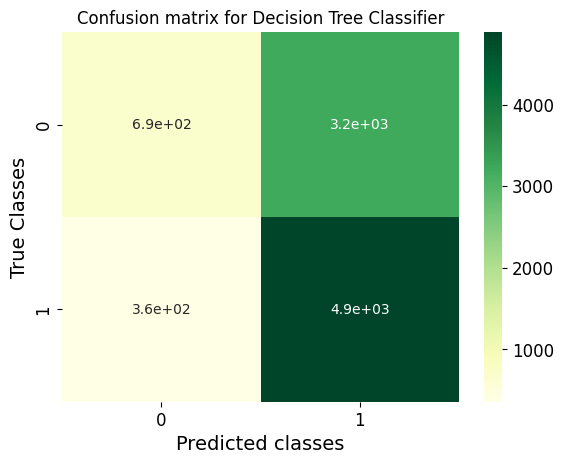

In [ ]:
print(f"Decision Tree accuracy_score: {accuracy_score(y_test, tree_y_pred)}")
print(f"Decision Tree precision_score: {precision_score(y_test, tree_y_pred)}")
print(f"Decision Tree recall_score: {recall_score(y_test, tree_y_pred)}")
print(f"Decision Tree f1_score: {f1_score(y_test, tree_y_pred)}")
print(f"Decision Tree roc_auc_score: {roc_auc_score(y_test, tree_y_pred_proba[:,1])}")

print('test accuracy for Decision Tree Classifier:'\
      , round(accuracy_score(y_test, tree_y_pred)*100, 2), '%')
plt.title('Confusion matrix for Decision Tree Classifier')
sns.heatmap(confusion_matrix(y_test, tree_y_pred), annot=True, cmap="YlGn")
plt.xlabel('Predicted classes')
plt.ylabel('True Classes')
plt.show()

# Hyperparameter Search

Now that we have decided on having a bin threshold of 10 minutes, we perform some hyperparameter search to see if we can improve our accuracy.  We will use RandomizedSearchCV to help us find better parameters.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Expanded parameter distribution
distri_v2 = {
    'max_depth': range(5, 25),
    'min_samples_leaf': range(1, 15),
    'min_samples_split': range(2, 20),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    # Cost Complexity Pruning - values usually between 0 and 0.05
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01],
    # Handling class imbalance
    'class_weight': [None, 'balanced'],
    'min_impurity_decrease': [0.0, 0.0001, 0.001]
}

tree_model_v2 = DecisionTreeClassifier(random_state=123)

random_search_v2 = RandomizedSearchCV(
    estimator=tree_model_v2,
    param_distributions=distri_v2,
    scoring='roc_auc',
    cv=5,
    n_iter=200,
    random_state=123,
    n_jobs=-1
)

random_search_v2.fit(X_train_transformed, y_train)

print("Best parameters found:", random_search_v2.best_params_)
print("\n", random_search_v2.best_estimator_)
print("Best ROC AUC Score from RandomizedSearchCV:", random_search_v2.best_score_)

Best parameters found: {'min_samples_split': 6, 'min_samples_leaf': 14, 'min_impurity_decrease': 0.0001, 'max_features': None, 'max_depth': 20, 'criterion': 'gini', 'class_weight': 'balanced', 'ccp_alpha': 0.0}

 DecisionTreeClassifier(class_weight='balanced', max_depth=20,
                       min_impurity_decrease=0.0001, min_samples_leaf=14,
                       min_samples_split=6, random_state=123)
Best ROC AUC Score from RandomizedSearchCV: 0.6653614555213262


In [ ]:
print("\n", random_search_v2.best_estimator_)


 DecisionTreeClassifier(class_weight='balanced', max_depth=20,
                       min_impurity_decrease=0.0001, min_samples_leaf=14,
                       min_samples_split=6, random_state=123)


In [ ]:
# let's use the parameters to train our model and see if our results improve

randomCV_final = DecisionTreeClassifier(max_depth=22, min_impurity_decrease=0.0001,
                       min_samples_split=19, random_state=123)

#randomCV_final = DecisionTreeClassifier(criterion='entropy', max_depth=15, max_features='sqrt',
#                       min_samples_leaf=7, min_samples_split=3,
#                       random_state=123)

rand_start = time.time()
randomCV_final_cv_score = cross_val_score(randomCV_final, X_train_transformed, y_train, cv=5)
rand_end = time.time()
rand_time = rand_end - rand_start
print('Final Decision Tree mean accuracy: ', round(randomCV_final_cv_score.mean()*100, 3), '% std: ', round(randomCV_final_cv_score.var()*100, 3),'%')
print(f"cross_val_score of DecisionTreeClassifier took {rand_time:.4f} seconds to run")


Final Decision Tree mean accuracy:  63.411 % std:  0.001 %
cross_val_score of DecisionTreeClassifier took 0.5018 seconds to run


Final Decision Tree accuracy_score: 0.6423
Final Decision Tree precision_score: 0.6594
Final Decision Tree recall_score: 0.7803
Final Decision Tree f1_score: 0.7147
Final Decision Tree roc_auc_score: 0.6829


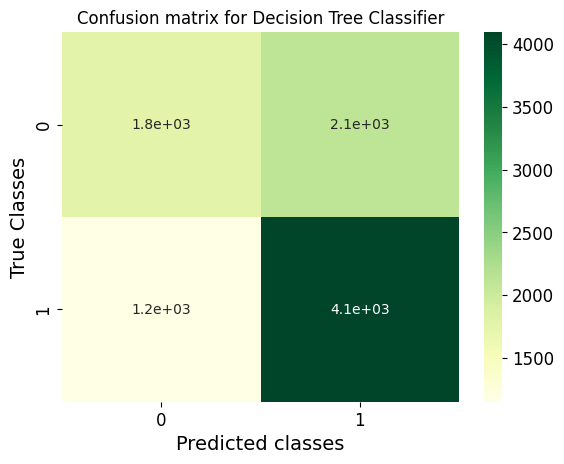

In [ ]:
# try out the test set
# do the fit
randomCV_final.fit(X_train_transformed, y_train)

# do the predict using test set
randomCV_final_y_pred = randomCV_final.predict(X_test_transformed)
randomCV_final_y_pred_proba = randomCV_final.predict_proba(X_test_transformed)

evaluation_metrics['Decision Tree Best'] = {
    'accuracy': accuracy_score(y_test, randomCV_final_y_pred),
    'precision': precision_score(y_test, randomCV_final_y_pred, average='weighted', zero_division=0),
    'recall': recall_score(y_test, randomCV_final_y_pred, average='weighted', zero_division=0),
    'f1_score': f1_score(y_test, randomCV_final_y_pred, average='weighted', zero_division=0),
    'roc_auc': roc_auc_score(y_test, randomCV_final_y_pred_proba[:, 1]),
}

print(f"Final Decision Tree accuracy_score: {accuracy_score(y_test, randomCV_final_y_pred):.4f}")
print(f"Final Decision Tree precision_score: {precision_score(y_test, randomCV_final_y_pred):.4f}")

print(f"Final Decision Tree recall_score: {recall_score(y_test, randomCV_final_y_pred):.4f}")
print(f"Final Decision Tree f1_score: {f1_score(y_test, randomCV_final_y_pred):.4f}")
print(f"Final Decision Tree roc_auc_score: {roc_auc_score(y_test, randomCV_final_y_pred_proba[:,1]):.4f}")

plt.title('Confusion matrix for Decision Tree Classifier')
sns.heatmap(confusion_matrix(y_test, randomCV_final_y_pred), annot=True, cmap="YlGn")
plt.xlabel('Predicted classes')
plt.ylabel('True Classes')
plt.show()

After some hyperparameter search, the best training accuracy achieved is 63.63%.  The DecisionTreeClassifier has the following hyperparameters:
 * max_depth=22
 * min_impurity_decrease=0.0001,
 * min_samples_split=19
 * random_state=123

The test accuracy is slightly better at 64.2%. The F1 score is not too bad at 0.722.




# Learning Curve

Now I wil plot the learning curve to see if my model is overfitting or underfitting.

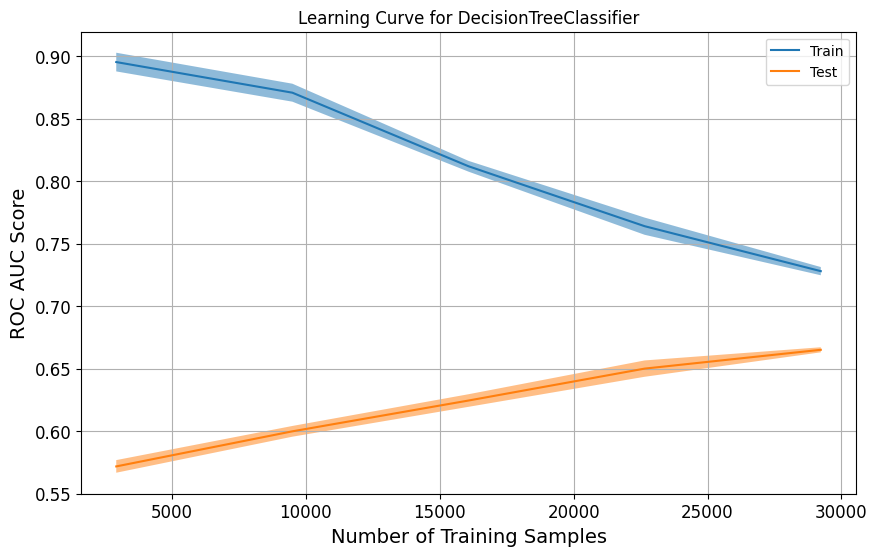

In [ ]:
from sklearn.model_selection import LearningCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
LearningCurveDisplay.from_estimator(
    randomCV_final,
    X_train_transformed,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    ax=ax
)
ax.set_title("Learning Curve for DecisionTreeClassifier")
ax.set_xlabel("Number of Training Samples")
ax.set_ylabel("ROC AUC Score")
ax.grid(True)
plt.show()

The Learning Curve of the DecisionTreeClassifier actually looks really good!  I am happy wth our model, although we can always explore additional models to see if we can improve upon this result.


___________

In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
import time

forest_pipeline = Pipeline([
  ('preprocessor', pipeline_full),
  ('rf_clf', RandomForestClassifier(random_state=123))
])

param_grid_rf = {
    'rf_clf__n_estimators': range(100, 500, 50),
    'rf_clf__max_depth': range(5, 25, 5),
    'rf_clf__min_samples_split': range(2, 20, 2),
    'rf_clf__min_samples_leaf': range(1, 15, 2)
}

grid_search_rf = RandomizedSearchCV(
    estimator=forest_pipeline,
    param_distributions=param_grid_rf,
    scoring='roc_auc',
    cv=5,
    n_iter=100,
    random_state=123,
    n_jobs=-1
)

start_time_rf_clf = time.time()
grid_search_rf.fit(X_train, y_train)
end_time_rf_clf = time.time()

print('Random Forest best ROC AUC Score from RandomizedSearchCV:', grid_search_rf.best_score_)

time_rf_clf = end_time_rf_clf - start_time_rf_clf

print(f"RandomizedSearchCV for RandomForestClassifier took {time_rf_clf:.4f} seconds to run")

print("Best parameters found for Random Forest:", grid_search_rf.best_params_)

Random Forest best ROC AUC Score from RandomizedSearchCV: 0.7042056185893477
RandomizedSearchCV for RandomForestClassifier took 286.1452 seconds to run
Best parameters found for Random Forest: {'rf_clf__n_estimators': 450, 'rf_clf__min_samples_split': 12, 'rf_clf__min_samples_leaf': 3, 'rf_clf__max_depth': 20}


In [ ]:
best_rf_model = grid_search_rf.best_estimator_
print("\nBest Random Forest Hyperparameters:", grid_search_rf.best_params_)


Best Random Forest Hyperparameters: {'rf_clf__n_estimators': 450, 'rf_clf__min_samples_split': 12, 'rf_clf__min_samples_leaf': 3, 'rf_clf__max_depth': 20}


In [ ]:
y_pred_forest = best_rf_model.predict(X_test)

In [ ]:
predict_proba_positives_forest = best_rf_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, classification_report

precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_test, predict_proba_positives_forest)
fpr_forest, tpr_forest, thresholds_frst = roc_curve(y_test, predict_proba_positives_forest)

precision_score_forest = precision_score(y_test, y_pred_forest)
recall_score_forest = recall_score(y_test, y_pred_forest)
f1_score_forest = f1_score(y_test, y_pred_forest)
test_roc_auc_forest = roc_auc_score(y_test, predict_proba_positives_forest)

evaluation_metrics['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_forest),
    'precision': precision_score_forest,
    'recall': recall_score_forest,
    'f1_score': f1_score_forest,
    'roc_auc': test_roc_auc_forest,
}

print("After running a Random Forest final model predict on the Test Set the scores are:")
print(" - Accuracy Score: ", accuracy_score(y_test, y_pred_forest))
print(" - Precision Score: ",precision_score_forest)
print(" - Recall Score:", recall_score_forest)
print(" - F1 Score: ", f1_score_forest)
print(" - ROC AUC Score: ", test_roc_auc_forest)

After running a Random Forest final model predict on the Test Set the scores are:
 - Accuracy Score:  0.6613026819923372
 - Precision Score:  0.6743319838056681
 - Recall Score: 0.793596340766152
 - F1 Score:  0.7291192435650499
 - ROC AUC Score:  0.7111103219084235


In [ ]:
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.63      0.48      0.55      3888
           1       0.67      0.79      0.73      5247

    accuracy                           0.66      9135
   macro avg       0.65      0.64      0.64      9135
weighted avg       0.66      0.66      0.65      9135



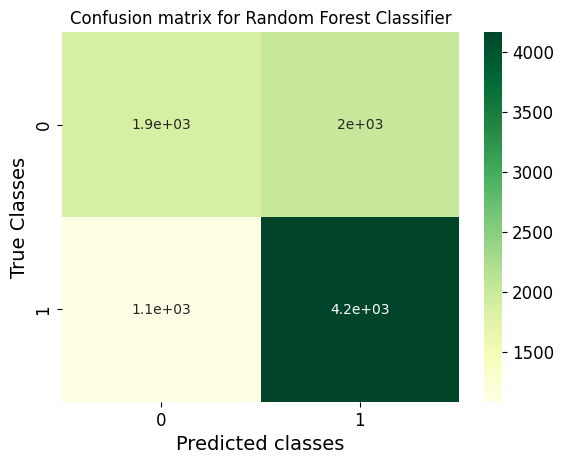

In [ ]:
plt.title('Confusion matrix for Random Forest Classifier')
sns.heatmap(confusion_matrix(y_test, y_pred_forest), annot=True, cmap="YlGn")
plt.xlabel('Predicted classes')
plt.ylabel('True Classes')
plt.show()

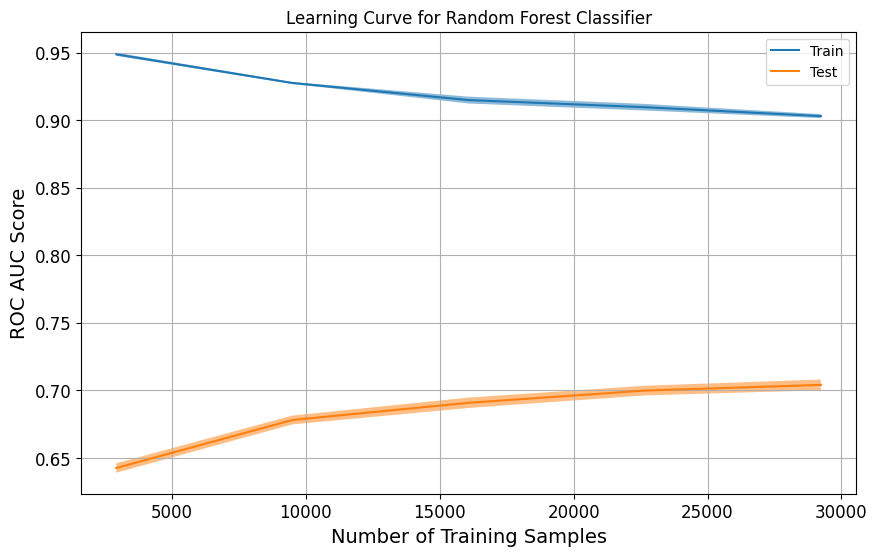

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
LearningCurveDisplay.from_estimator(best_rf_model,
                                    X_train,
                                    y_train,
                                    cv=5,
                                    random_state=123,
                                    n_jobs=-1,
                                    ax=ax, scoring='roc_auc', train_sizes=np.linspace(0.1, 1.0, 5))
plt.title("Learning Curve for Random Forest Classifier")
plt.xlabel("Number of Training Samples")
plt.ylabel("ROC AUC Score")
plt.grid(True)
plt.show()

Learning curve analysis shows overfitting of data!

In [ ]:
# Install XGBoost if not already installed
#!pip install xgboost

In [ ]:
# XGBoost Classifier
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
  ('preprocessor', pipeline_full),
  ('xgb_clf', XGBClassifier(random_state=123))
])

param_grid_xgb = {
    'xgb_clf__n_estimators': range(100, 500, 50),
    'xgb_clf__max_depth': range(3, 15, 2),
    'xgb_clf__learning_rate': [0.01, 0.1, 0.2]
}

grid_search_xgb = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid_xgb,
    scoring='roc_auc',
    cv=5,
    n_iter=100,
    random_state=123,
    n_jobs=-1
)

start_time_xgb_clf = time.time()
grid_search_xgb.fit(X_train, y_train)
end_time_xgb_clf = time.time()

print('XGBoost Best model ROC AUC Score: ', grid_search_xgb.best_score_)
print('XGBoost Best parameter Search Time for RandomizedSearchCV: ', round(end_time_xgb_clf - start_time_xgb_clf, 3), ' seconds')

XGBoost Best model ROC AUC Score:  0.6978631461873362
XGBoost Best parameter Search Time for RandomizedSearchCV:  81.856  seconds


In [ ]:
best_xgb_model = grid_search_xgb.best_estimator_
print("\nBest XGBoost Hyperparameters:", grid_search_xgb.best_params_)


Best XGBoost Hyperparameters: {'xgb_clf__n_estimators': 450, 'xgb_clf__max_depth': 9, 'xgb_clf__learning_rate': 0.01}


In [ ]:
y_predict_xgb = best_xgb_model.predict(X_test)
y_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_test, y_proba_xgb)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_proba_xgb)

precision_score_xgb = precision_score(y_test, y_predict_xgb)
recall_score_xgb = recall_score(y_test, y_predict_xgb)
f1_score_xgb = f1_score(y_test, y_predict_xgb)
test_roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

evaluation_metrics['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_predict_xgb),
    'precision': precision_score_xgb,
    'recall': recall_score_xgb,
    'f1_score': f1_score_xgb,
    'roc_auc': test_roc_auc_xgb,
}

print("After running XGBoost final model predict on the Test Set the scores are:")
print(" - Accuracy Score: ", accuracy_score(y_test, y_predict_xgb))
print(" - Precision Score: ",precision_score_xgb)
print(" - Recall Score:", recall_score_xgb)
print(" - F1 Score: ", f1_score_xgb)
print(" - ROC AUC Score: ", test_roc_auc_xgb)

After running XGBoost final model predict on the Test Set the scores are:
 - Accuracy Score:  0.6559386973180077
 - Precision Score:  0.6638629283489097
 - Recall Score: 0.8122736801982084
 - F1 Score:  0.730607696922945
 - ROC AUC Score:  0.7051144402719641


In [ ]:
print(classification_report(y_test, y_predict_xgb))

              precision    recall  f1-score   support

           0       0.64      0.44      0.52      3888
           1       0.66      0.81      0.73      5247

    accuracy                           0.66      9135
   macro avg       0.65      0.63      0.63      9135
weighted avg       0.65      0.66      0.64      9135



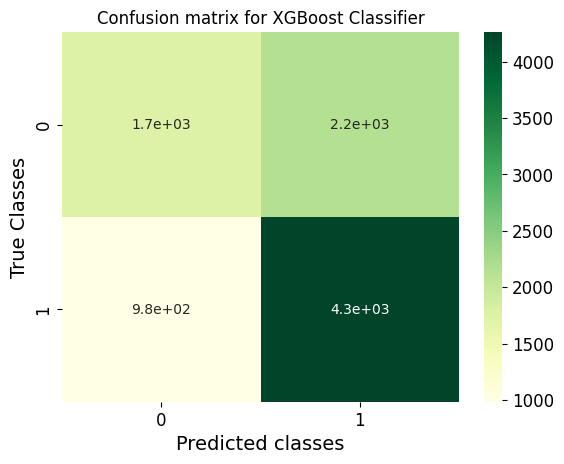

In [ ]:
plt.title('Confusion matrix for XGBoost Classifier')
sns.heatmap(confusion_matrix(y_test, y_predict_xgb), annot=True, cmap="YlGn")
plt.xlabel('Predicted classes')
plt.ylabel('True Classes')
plt.show()

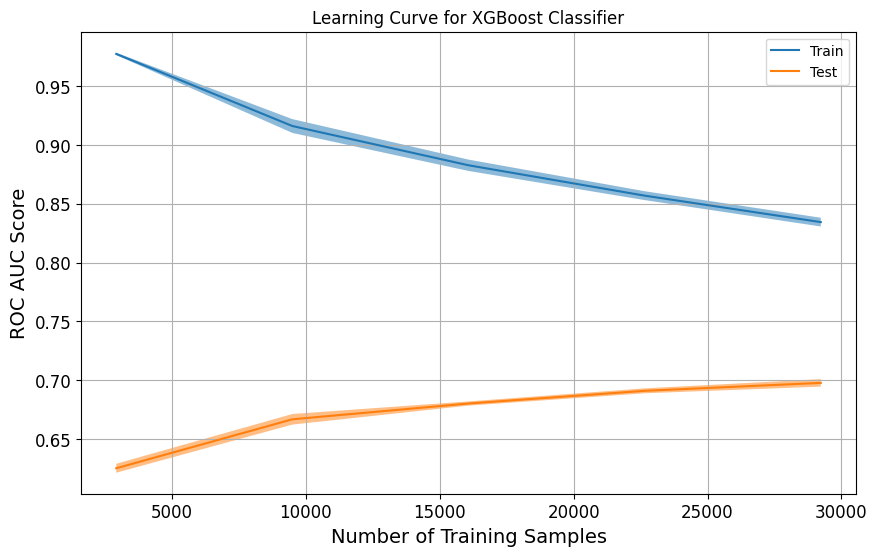

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
LearningCurveDisplay.from_estimator(best_xgb_model,
                                    X_train,
                                    y_train,
                                    cv=5,
                                    random_state=123,
                                    n_jobs=-1,
                                    ax=ax, scoring='roc_auc', train_sizes=np.linspace(0.1, 1.0, 5))
plt.title("Learning Curve for XGBoost Classifier")
plt.xlabel("Number of Training Samples")
plt.ylabel("ROC AUC Score")
plt.grid(True)
plt.show()

The Learning curve analysis shows slightly better results than Random Forest, however both models show overfitting.

In [ ]:
# Let's try AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), random_state=123
)
ada_clf.fit(X_train_transformed, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",123
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [ ]:
y_pred_ada = ada_clf.predict(X_test_transformed)
y_proba_ada = ada_clf.predict_proba(X_test_transformed)[:, 1]

In [ ]:
precisions_ada, recalls_ada, thresholds_ada = precision_recall_curve(y_test, y_proba_ada)
fpr_ada, tpr_ada, thresholds_ada = roc_curve(y_test, y_proba_ada)

precision_score_ada = precision_score(y_test, y_pred_ada)
recall_score_ada = recall_score(y_test, y_pred_ada)
f1_score_ada = f1_score(y_test, y_pred_ada)
test_roc_auc_ada = roc_auc_score(y_test, y_proba_ada)

evaluation_metrics['AdaBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred_ada),
    'precision': precision_score_ada,
    'recall': recall_score_ada,
    'f1_score': f1_score_ada,
    'roc_auc': test_roc_auc_ada,
}

print("After running AdaBoost model on the Test Set the scores are:")
print(" - Accuracy Score: ", accuracy_score(y_test, y_pred_ada))
print(" - Precision Score: ",precision_score_ada)
print(" - Recall Score:", recall_score_ada)
print(" - F1 Score: ", f1_score_ada)
print(" - ROC AUC Score: ", test_roc_auc_ada)

After running AdaBoost model on the Test Set the scores are:
 - Accuracy Score:  0.6123700054734538
 - Precision Score:  0.6130699893955461
 - Recall Score: 0.8814560701353155
 - F1 Score:  0.7231647251974044
 - ROC AUC Score:  0.6327513919378582


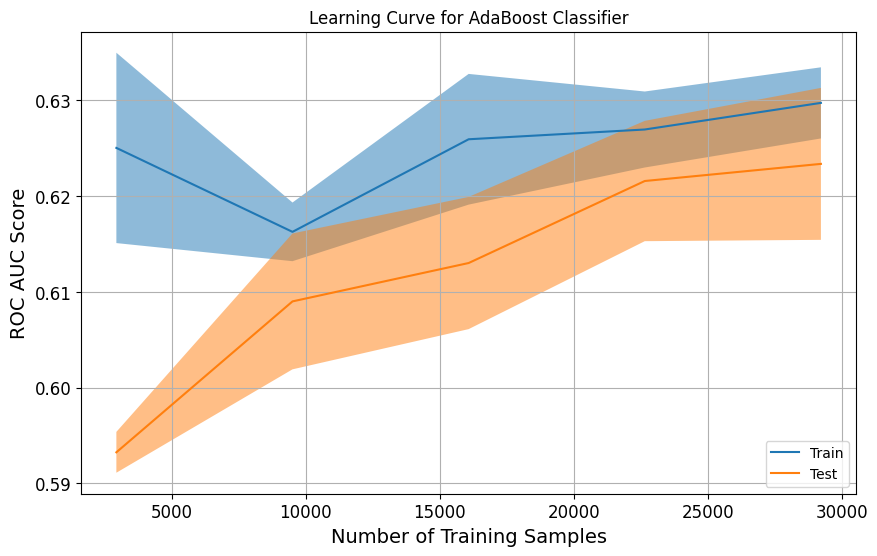

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
LearningCurveDisplay.from_estimator(ada_clf,
                                    X_train_transformed,
                                    y_train,
                                    cv=5,
                                    random_state=123,
                                    n_jobs=-1,
                                    ax=ax, scoring='roc_auc', train_sizes=np.linspace(0.1, 1.0, 5))
plt.title("Learning Curve for AdaBoost Classifier")
plt.xlabel("Number of Training Samples")
plt.ylabel("ROC AUC Score")
plt.grid(True)
plt.show()

In [ ]:
evaluation_metrics_df = pd.DataFrame(evaluation_metrics).T
display(evaluation_metrics_df)

,accuracy,precision,recall,f1_score,roc_auc
Decision Tree Initial,0.610509,0.626878,0.610509,0.540039,0.619163
Decision Tree Best,0.642255,0.636630,0.642255,0.632022,0.682876
Random Forest,0.661303,0.674332,0.793596,0.729119,0.711110
XGBoost,0.655939,0.663863,0.812274,0.730608,0.705114
AdaBoost,0.612370,0.613070,0.881456,0.723165,0.632751


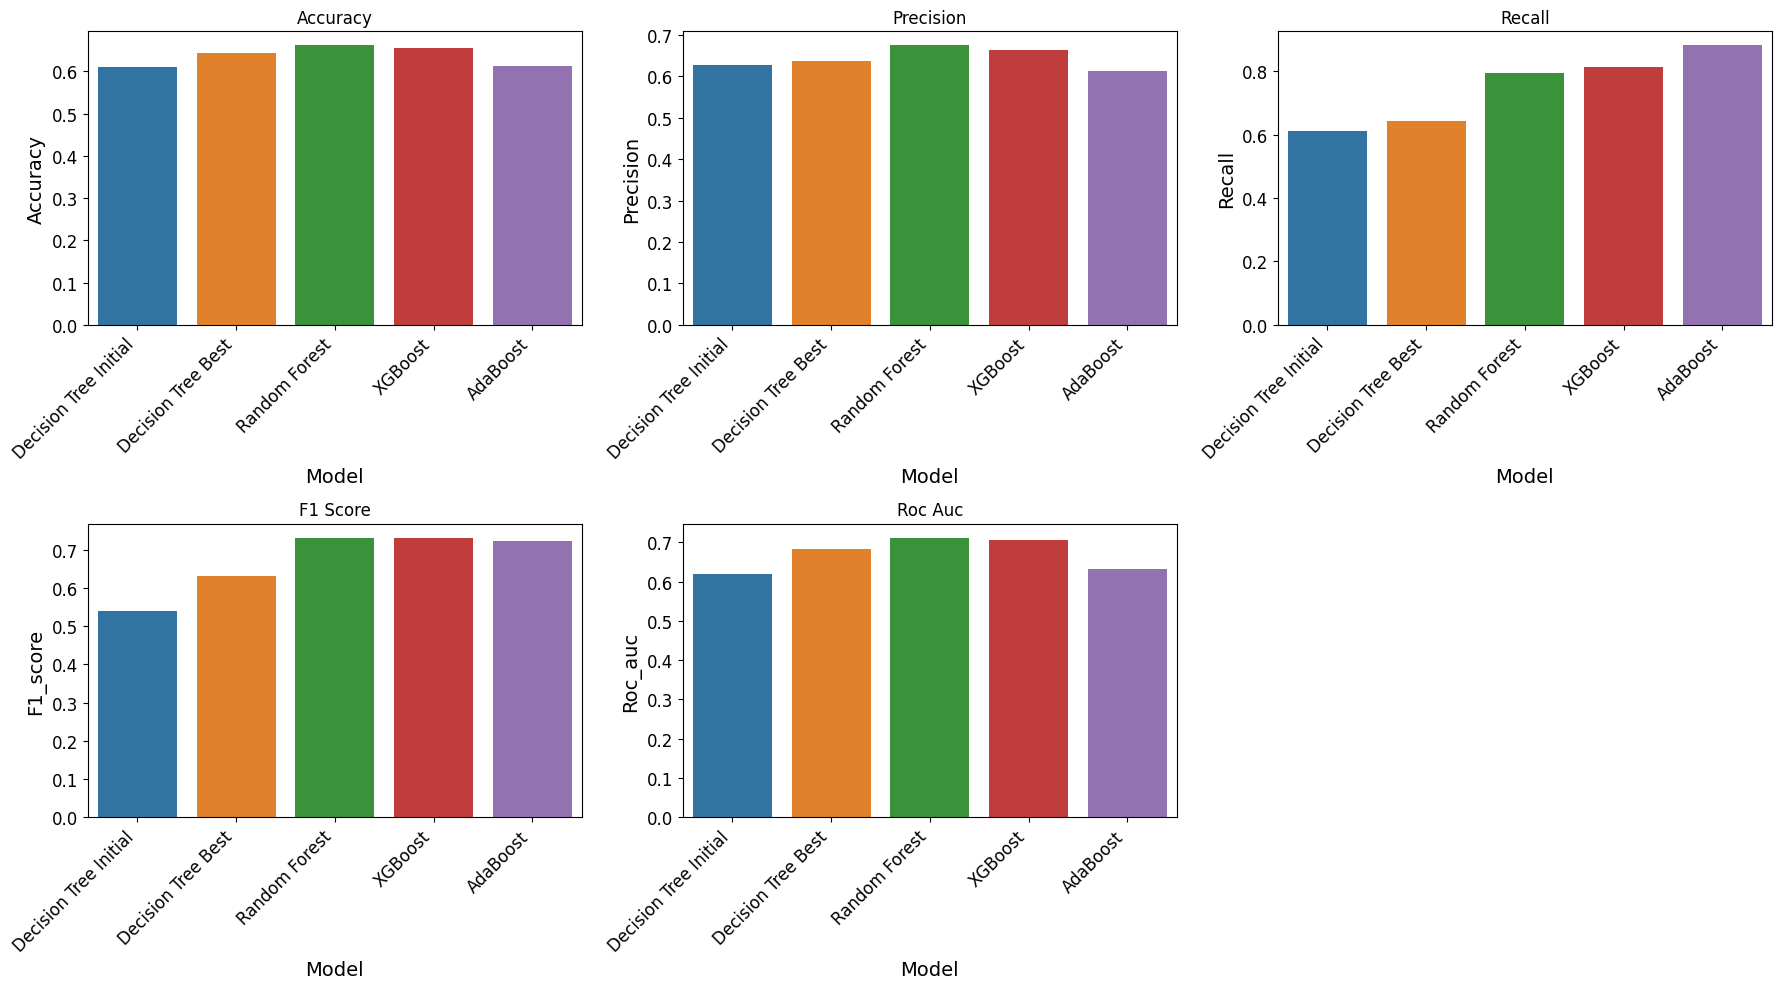

In [ ]:
# plotting the evaluation metrics for all models
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
fig, axes = plt.subplots(2, 3, figsize=(18, 10));
axes = axes.flatten();
for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x=evaluation_metrics_df.index, y=metric, data=evaluation_metrics_df,
                ax=axes[i], palette='tab10', hue=evaluation_metrics_df.index);
    axes[i].set_title(f'{metric.title().replace("_", " ")}');
    axes[i].set_xlabel('Model');
    axes[i].set_ylabel(metric.capitalize());

    ticks_loc = axes[i].get_xticks()
    axes[i].set_xticks(ticks_loc)

    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right');

axes[-1].remove();
plt.tight_layout();
plt.show();